In [1]:
# ============================================================
# F7 — Week 06 Black-Box Optimisation
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# Goal: MAXIMISE y
# X: 6D in [0,1], y: scalar
# ============================================================

# ---------------------------
# Imports
# ---------------------------
import os
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

from scipy.stats import norm


In [2]:
# ---------------------------
# 0) Config
# ---------------------------
np.random.seed(42)

INPUTS_PATH  = "data/F7/initial_inputs.npy"
OUTPUTS_PATH = "data/F7/initial_outputs.npy"

# If you're running locally and the folders don't exist yet:
os.makedirs("data/F7", exist_ok=True)
os.makedirs("outputs/F7", exist_ok=True)

@dataclass
class BOConfig:
    # Candidate generation
    n_global: int = 6000
    n_local: int = 2500

    # Week 06: tighter local refinement (micro-tuning)
    # If you'd like to force equal scales, set all entries to the same value.
    local_scales: tuple = (0.03, 0.03, 0.03, 0.03, 0.03, 0.03)

    # Acquisition
    xi: float = 0.01  # small positive: slightly exploitative EI

    # Diversity / anti-duplicate
    min_dist: float = 0.02  # reject candidates too close to existing points

    # Models
    rf_n_estimators: int = 600
    rf_min_samples_leaf: int = 2

    gbm_ensemble_size: int = 12
    gbm_max_depth: int = 3
    gbm_learning_rate: float = 0.05
    gbm_n_estimators: int = 450

    # Diagnostics
    cv_folds: int = 5

cfg = BOConfig()


In [3]:
# ---------------------------
# 1) Load
# ---------------------------
def safe_load_npy(path: str):
    # Primary path (repo structure)
    if os.path.exists(path):
        return np.load(path)
    # Fallback: mounted files (e.g., grading environment)
    alt = os.path.join("/mnt/data", os.path.basename(path))
    if os.path.exists(alt):
        return np.load(alt)
    raise FileNotFoundError(f"Could not find {path} (or {alt}).")

X = safe_load_npy(INPUTS_PATH)
y = safe_load_npy(OUTPUTS_PATH)

X = np.asarray(X, dtype=float)
y = np.asarray(y, dtype=float).ravel()

n, d = X.shape
assert d == 6, f"Expected 6D inputs for F7, got d={d}."
assert len(y) == n, "X and y length mismatch."

y_best = float(np.max(y))
x_best = X[int(np.argmax(y))]

print(f"Loaded X shape: {X.shape}, y shape: {y.shape}")
print(f"Current best observed y: {y_best:.6f}")
print(f"Current best x: {np.round(x_best, 6)}")


Loaded X shape: (35, 6), y shape: (35,)
Current best observed y: 1.709144
Current best x: [0.003252 0.429211 0.241324 0.213397 0.354398 0.734586]


In [4]:
# ---------------------------
# 2) Surrogate
# ---------------------------

# --- Gaussian Process (with standardisation) ---
x_scaler = StandardScaler()
y_scaler = StandardScaler()

Xs = x_scaler.fit_transform(X)
ys = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

kernel = (
    C(1.0, (1e-3, 1e3))
    * RBF(length_scale=np.ones(d), length_scale_bounds=(1e-3, 1e3))
    + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e-2))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,
    normalize_y=False,
    n_restarts_optimizer=1,
    random_state=42,
)
gp.fit(Xs, ys)

# --- Random Forest ---
rf = RandomForestRegressor(
    n_estimators=cfg.rf_n_estimators,
    min_samples_leaf=cfg.rf_min_samples_leaf,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X, y)

# --- GBM Ensemble ---
gbm_ensemble = []
for k in range(cfg.gbm_ensemble_size):
    gbm = GradientBoostingRegressor(
        random_state=100 + k,
        max_depth=cfg.gbm_max_depth,
        learning_rate=cfg.gbm_learning_rate,
        n_estimators=cfg.gbm_n_estimators,
    )
    gbm.fit(X, y)
    gbm_ensemble.append(gbm)

print("Surrogates trained: GP, RF, GBM-ensemble")


C:\Users\elena\anaconda3\envs\Imperialtest\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\elena\anaconda3\envs\Imperialtest\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Surrogates trained: GP, RF, GBM-ensemble


In [5]:
# ---------------------------
# 3) Acquisition (Expected Improvement, MAXIMISE)
# ---------------------------
def expected_improvement(mu, sigma, y_best, xi=0.0):
    # EI for maximisation
    sigma = np.asarray(sigma, dtype=float)
    mu = np.asarray(mu, dtype=float)
    sigma = np.maximum(sigma, 1e-12)

    imp = mu - y_best - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma <= 1e-12, np.maximum(imp, 0.0), ei)

def gp_predict_mu_sigma(Xcand):
    Xs_c = x_scaler.transform(Xcand)
    mu_s, std_s = gp.predict(Xs_c, return_std=True)
    mu = y_scaler.inverse_transform(mu_s.reshape(-1, 1)).ravel()
    std = std_s * y_scaler.scale_[0]
    return mu, std

def rf_predict_mu_sigma(Xcand):
    # mean from forest prediction; std across trees
    mu = rf.predict(Xcand)
    all_tree = np.stack([t.predict(Xcand) for t in rf.estimators_], axis=0)
    std = np.std(all_tree, axis=0)
    return mu, std

def gbm_predict_mu_sigma(Xcand):
    preds = np.stack([m.predict(Xcand) for m in gbm_ensemble], axis=0)
    mu = np.mean(preds, axis=0)
    std = np.std(preds, axis=0)
    return mu, std

def sample_candidates():
    # Global uniform
    Xg = np.random.rand(cfg.n_global, d)

    # Local perturbations around current best
    scales = np.array(cfg.local_scales, dtype=float).reshape(1, -1)
    Xl = x_best.reshape(1, -1) + np.random.normal(0.0, scales, size=(cfg.n_local, d))
    Xl = np.clip(Xl, 0.0, 1.0)

    Xcand = np.vstack([Xg, Xl])

    # Diversity filter: remove candidates too close to existing points
    # (simple L2 check; vectorised for speed)
    diffs = Xcand[:, None, :] - X[None, :, :]
    dists = np.sqrt(np.sum(diffs**2, axis=2))
    min_d = np.min(dists, axis=1)

    keep = min_d >= cfg.min_dist
    Xcand = Xcand[keep]
    min_d = min_d[keep]

    return Xcand, min_d

Xcand, cand_min_dist = sample_candidates()
print(f"Candidates after min-dist filter: {len(Xcand):,} (min_dist={cfg.min_dist})")

# Predict + EI per model
mu_gp, sd_gp = gp_predict_mu_sigma(Xcand)
mu_rf, sd_rf = rf_predict_mu_sigma(Xcand)
mu_gb, sd_gb = gbm_predict_mu_sigma(Xcand)

ei_gp = expected_improvement(mu_gp, sd_gp, y_best=y_best, xi=cfg.xi)
ei_rf = expected_improvement(mu_rf, sd_rf, y_best=y_best, xi=cfg.xi)
ei_gb = expected_improvement(mu_gb, sd_gb, y_best=y_best, xi=cfg.xi)

ei_blend = (ei_gp + ei_rf + ei_gb) / 3.0

best_idx = int(np.argmax(ei_blend))
x_next = Xcand[best_idx]
acq_details = {
    "blend_ei": float(ei_blend[best_idx]),
    "gp_ei": float(ei_gp[best_idx]),
    "rf_ei": float(ei_rf[best_idx]),
    "gbm_ei": float(ei_gb[best_idx]),
    "cand_min_dist_to_data": float(cand_min_dist[best_idx]),
    "pred_mu_gp": float(mu_gp[best_idx]),
    "pred_mu_rf": float(mu_rf[best_idx]),
    "pred_mu_gbm": float(mu_gb[best_idx]),
}

print("Selected candidate (argmax blended EI).")
print("x_next:", np.round(x_next, 6))
print("details:", {k: round(v, 6) for k, v in acq_details.items()})


Candidates after min-dist filter: 8,494 (min_dist=0.02)
Selected candidate (argmax blended EI).
x_next: [0.       0.362382 0.194454 0.185737 0.331753 0.721541]
details: {'blend_ei': 0.030165, 'gp_ei': 0.043102, 'rf_ei': 0.047392, 'gbm_ei': 0.0, 'cand_min_dist_to_data': 0.09012, 'pred_mu_gp': 1.750262, 'pred_mu_rf': 1.187713, 'pred_mu_gbm': 1.441201}


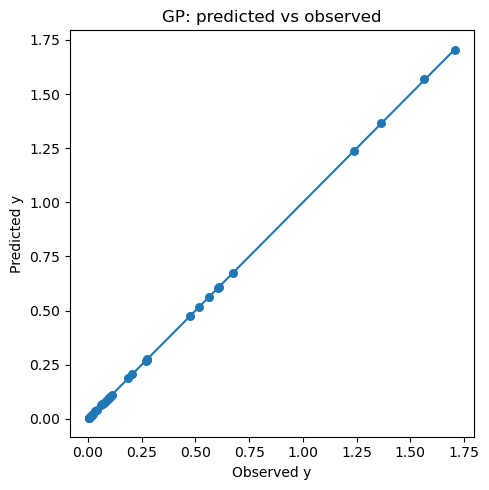

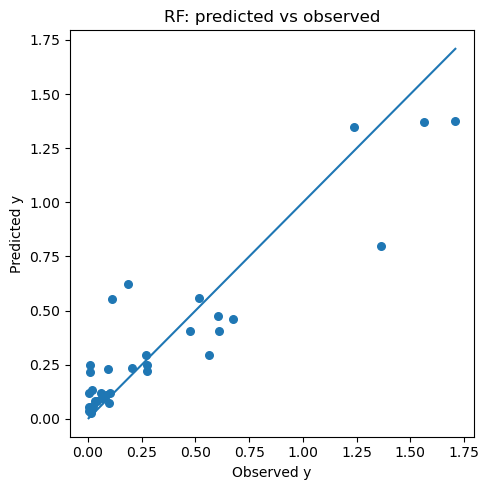

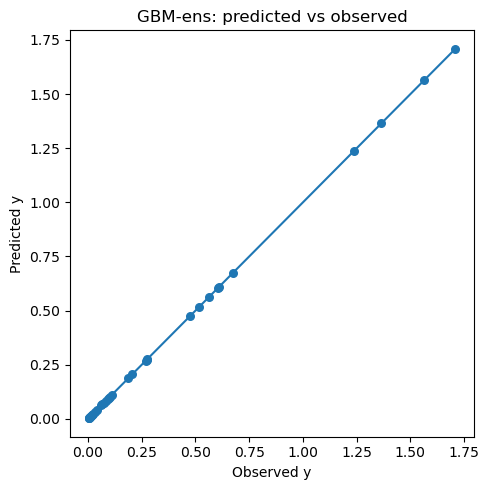

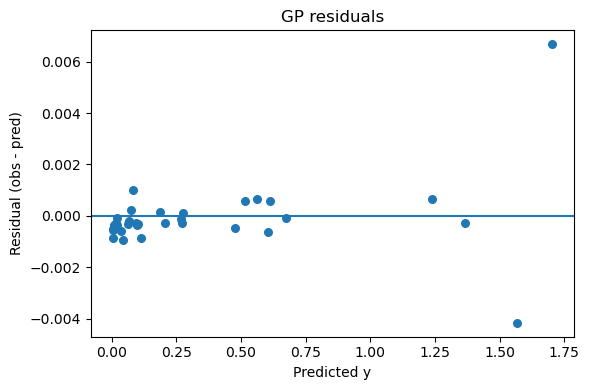

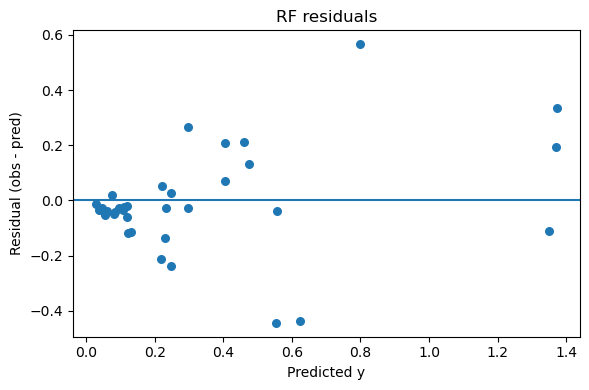

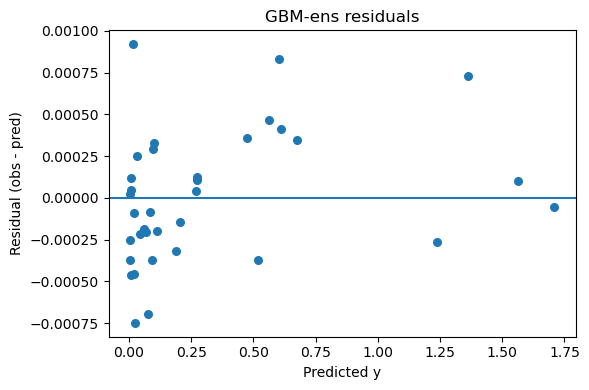

[CV RF] RMSE=0.367522, R2=0.3631
[CV GBM] RMSE=0.342933, R2=0.4455


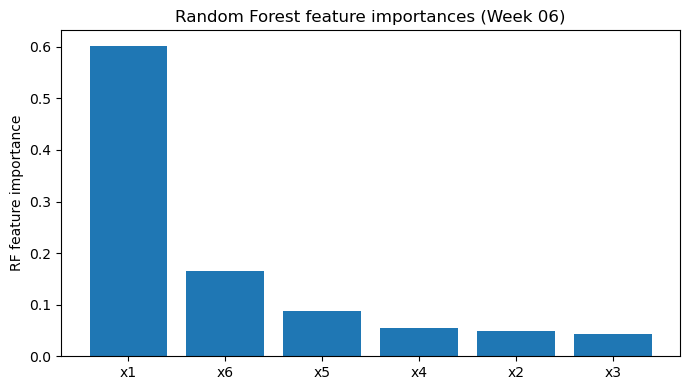

RF importances (descending):
  x1: 0.6019
  x6: 0.1654
  x5: 0.0876
  x4: 0.0544
  x2: 0.0484
  x3: 0.0424

Diversity checks:
  nearest distance to existing data: 0.090120
  median distance to existing data:  0.925804
  distance to current best x_best:   0.090120


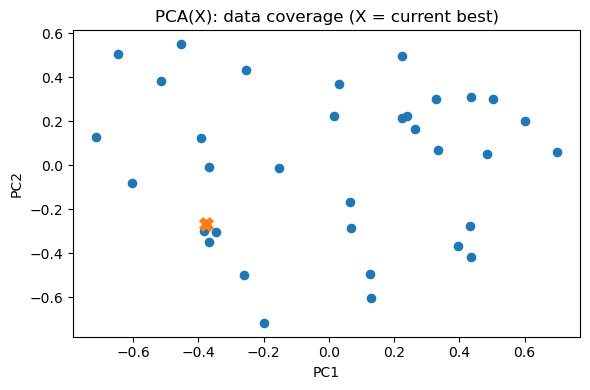

In [6]:
# ---------------------------
# 4) Diagnostics
# ---------------------------

def plot_pred_vs_obs(y_true, y_pred, title, outpath=None):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, s=30)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi])
    plt.xlabel("Observed y")
    plt.ylabel("Predicted y")
    plt.title(title)
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=200)
    plt.show()

def plot_residuals(y_true, y_pred, title, outpath=None):
    res = y_true - y_pred
    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, res, s=30)
    plt.axhline(0.0)
    plt.xlabel("Predicted y")
    plt.ylabel("Residual (obs - pred)")
    plt.title(title)
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=200)
    plt.show()

# In-sample predictions (quick health check)
mu_gp_train, _ = gp_predict_mu_sigma(X)
mu_rf_train = rf.predict(X)
mu_gb_train = np.mean(np.stack([m.predict(X) for m in gbm_ensemble], axis=0), axis=0)

plot_pred_vs_obs(y, mu_gp_train, "GP: predicted vs observed", "outputs/F7/week06_gp_pred_vs_obs.png")
plot_pred_vs_obs(y, mu_rf_train, "RF: predicted vs observed", "outputs/F7/week06_rf_pred_vs_obs.png")
plot_pred_vs_obs(y, mu_gb_train, "GBM-ens: predicted vs observed", "outputs/F7/week06_gbm_pred_vs_obs.png")

plot_residuals(y, mu_gp_train, "GP residuals", "outputs/F7/week06_gp_residuals.png")
plot_residuals(y, mu_rf_train, "RF residuals", "outputs/F7/week06_rf_residuals.png")
plot_residuals(y, mu_gb_train, "GBM-ens residuals", "outputs/F7/week06_gbm_residuals.png")

# Quick CV report for RF and a single GBM (GP CV is slower; optional)
def crossval_report(model_builder, name):
    k = min(cfg.cv_folds, len(y))
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    preds = np.zeros_like(y, dtype=float)

    for tr, te in kf.split(X):
        m = model_builder()
        m.fit(X[tr], y[tr])
        preds[te] = m.predict(X[te])

    rmse = float(np.sqrt(mean_squared_error(y, preds)))
    r2 = float(r2_score(y, preds))
    print(f"[CV {name}] RMSE={rmse:.6f}, R2={r2:.4f}")

crossval_report(
    lambda: RandomForestRegressor(
        n_estimators=max(300, cfg.rf_n_estimators // 2),
        min_samples_leaf=cfg.rf_min_samples_leaf,
        random_state=42,
        n_jobs=-1,
    ),
    "RF",
)

crossval_report(
    lambda: GradientBoostingRegressor(
        random_state=42,
        max_depth=cfg.gbm_max_depth,
        learning_rate=cfg.gbm_learning_rate,
        n_estimators=cfg.gbm_n_estimators,
    ),
    "GBM",
)

# Feature importances (RF)
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.bar(range(d), importances[order])
plt.xticks(range(d), [f"x{j+1}" for j in order])
plt.ylabel("RF feature importance")
plt.title("Random Forest feature importances (Week 06)")
plt.tight_layout()
plt.savefig("outputs/F7/week06_rf_feature_importances.png", dpi=200)
plt.show()

print("RF importances (descending):")
for j in order:
    print(f"  x{j+1}: {importances[j]:.4f}")

# Region / diversity checks
# How far is x_next from the nearest existing point? (should not be ~0)
diffs_next = X - x_next.reshape(1, -1)
dists_next = np.sqrt(np.sum(diffs_next**2, axis=1))
print("\nDiversity checks:")
print(f"  nearest distance to existing data: {float(np.min(dists_next)):.6f}")
print(f"  median distance to existing data:  {float(np.median(dists_next)):.6f}")
print(f"  distance to current best x_best:   {float(np.linalg.norm(x_next - x_best)):.6f}")

# Simple 2D projection sanity check: PCA on X (not a model, just visual)
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)

plt.figure(figsize=(6, 4))
plt.scatter(Z[:, 0], Z[:, 1], s=35)
best_idx_obs = int(np.argmax(y))
plt.scatter(Z[best_idx_obs, 0], Z[best_idx_obs, 1], s=90, marker="X")
plt.title("PCA(X): data coverage (X = current best)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/F7/week06_pca_coverage.png", dpi=200)
plt.show()


In [7]:
# ---------------------------
# 5) Output
# ---------------------------
np.set_printoptions(suppress=True, precision=8)

print("\n====================================")
print("F7 Week 06 — Proposed next X (submit this one line)")
print("====================================")
print(x_next)

print("\nAcquisition details (blended EI):")
for k, v in acq_details.items():
    print(f"  {k}: {v}")

# Also save for convenience
np.save("outputs/F7/week06_x_next.npy", x_next)



F7 Week 06 — Proposed next X (submit this one line)
[0.         0.36238162 0.19445422 0.18573736 0.33175289 0.72154069]

Acquisition details (blended EI):
  blend_ei: 0.03016453742346822
  gp_ei: 0.043101775351848656
  rf_ei: 0.047391836918556
  gbm_ei: 2.8648485261718616e-18
  cand_min_dist_to_data: 0.09011966803574906
  pred_mu_gp: 1.7502622793243865
  pred_mu_rf: 1.187712727240405
  pred_mu_gbm: 1.4412010586925366
